(sec:xray)=
# X-ray spectroscopies

VeloxChem provides access to a range of X‑ray spectroscopies by combining density‑functional theory with response theory techniques that enable the description of core‑level excitations and their characteristic spectral signatures. These methods allow the simulation of X‑ray absorption, emission, and related core‑level properties, thereby enabling chemically intuitive interpretation of spectral features. For a comprehensive review of theoretical approaches to X‑ray spectroscopies, see {cite}`norman_cr_2018`.

The ESCA molecule, ethyl trifluoroacetate (CF₃–CO–O–CH₂–CH₃), became historically important in X‑ray and photoelectron spectroscopies because its C 1s photoelectron spectrum displays four well‑separated and chemically distinct carbon binding energies, spanning more than 8 eV—a uniquely clear demonstration of chemical shifts arising from different charge environments at individual atomic sites. This spectrum rapidly became the pedagogical showcase for ESCA (Electron Spectroscopy for Chemical Analysis) following Kai Siegbahn’s development of high‑resolution photoelectron spectroscopy in the 1960s, and it has since served as a benchmark for both experimental methodology and theoretical modeling of core‑level shifts. The molecule continues to be used in modern X‑ray and photoelectron studies as a canonical reference system to illustrate how core‑level binding energies encode local electronic structure and substituent effects, linking directly to the foundational ESCA work recognized in [Siegbahn’s 1981 Nobel Prize.](https://www.nobelprize.org/prizes/physics/1981/summary/)

In [1]:
import veloxchem as vlx 

molecule = vlx.Molecule.read_xyz_string("""13
b3lyp/def2-svp optimized geometry
C              1.326024532622         0.471089167011        -1.154937296389
C              0.484399509715         0.908494386259         0.037569541020
C              0.270494167717        -0.188493907246         1.053914467110
O              0.701245126416        -1.308212251798         0.971080711541
C             -0.582260522270         0.210893702941         2.291730106998
F             -0.731967860619        -0.799813015071         3.135965340271
F             -1.800383044157         0.625073687043         1.897202571864
F              0.003899498844         1.231896946553         2.943599980006
H              1.453639490166         1.302028888463        -1.864264306255
H              0.853135331881        -0.368249103011        -1.686230702784
H              2.322713498820         0.134038471332        -0.833394707486
H              0.936346512410         1.764030447212         0.571699332428
H             -0.514670521097         1.267150587304        -0.270103071648""")

molecule.show(atom_indices=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

(sec:xps)=
## XPS

X-ray Photoelectron Spectroscopy (XPS) probes the binding energies of core electrons and yields element-specific, chemically sensitive spectra in which each peak reflects the local electronic environment of an individual atomic site. In VeloxChem, XPS binding energies are obtained through the **ΔSCF approach**: a ground-state SCF calculation is performed first, followed by a separate *unrestricted* SCF calculation for each core-hole state (i.e., one core electron is removed from the targeted atom). The binding energy for each site is then computed as the difference in total energies between the core-ionized and ground states, along with a correction for relativistic and relaxation effects. The `XPSDriver` automates this workflow—it iterates over all atoms of the chosen element, generates the corresponding core-hole reference states, and assembles the final spectrum. 

**Python script**


                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

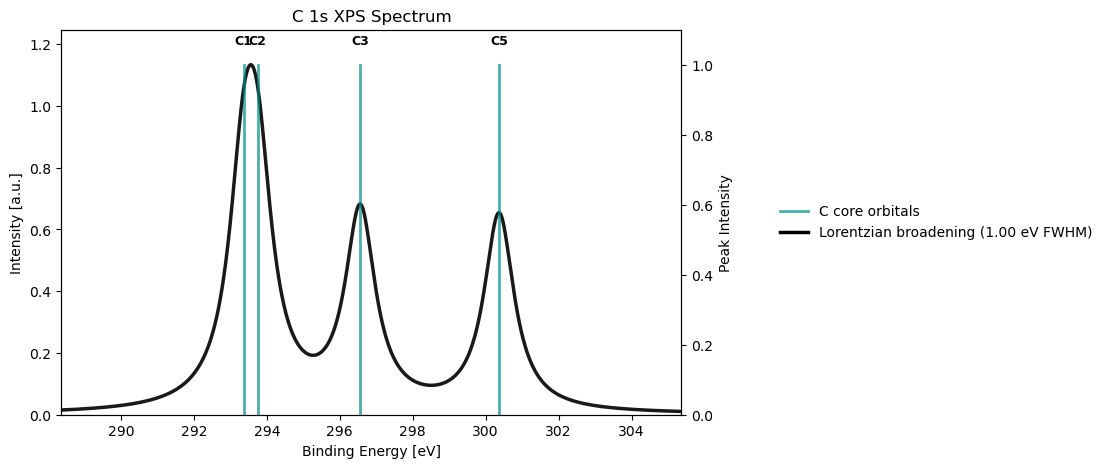

In [2]:
import veloxchem as vlx

molecule = vlx.Molecule.read_xyz_string("""13
ESCA b3lyp/def2-svp optimized geometry
C              1.326024532622         0.471089167011        -1.154937296389
C              0.484399509715         0.908494386259         0.037569541020
C              0.270494167717        -0.188493907246         1.053914467110
O              0.701245126416        -1.308212251798         0.971080711541
C             -0.582260522270         0.210893702941         2.291730106998
F             -0.731967860619        -0.799813015071         3.135965340271
F             -1.800383044157         0.625073687043         1.897202571864
F              0.003899498844         1.231896946553         2.943599980006
H              1.453639490166         1.302028888463        -1.864264306255
H              0.853135331881        -0.368249103011        -1.686230702784
H              2.322713498820         0.134038471332        -0.833394707486
H              0.936346512410         1.764030447212         0.571699332428
H             -0.514670521097         1.267150587304        -0.270103071648""")

basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

xps_drv = vlx.XPSDriver()

xps_results_c = xps_drv.compute(molecule, basis, scf_drv, element='C')
xps_drv.plot_spectrum(xps_results_c, element='C', broadening_type='lorentzian', broadening_value=1.0)

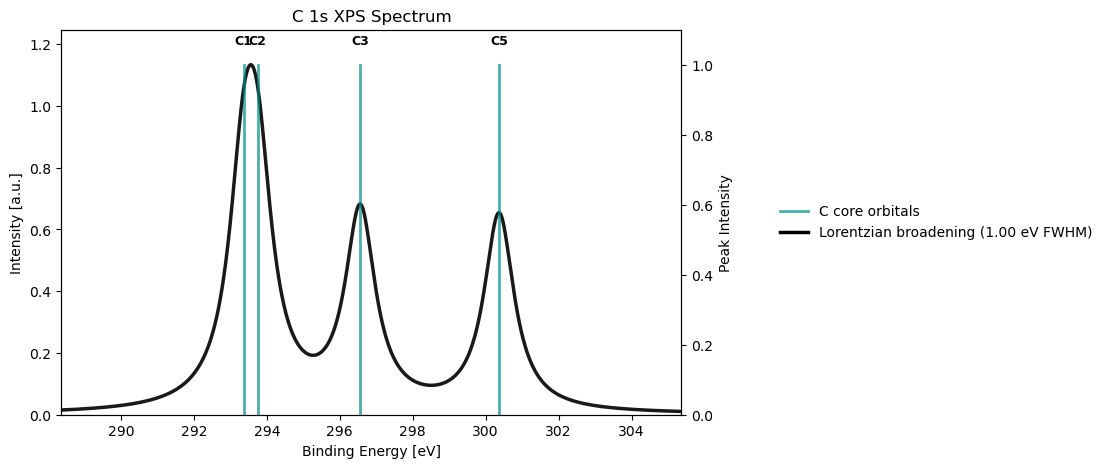

In [3]:
xps_drv.plot_spectrum(xps_results_c, element='C', broadening_type='lorentzian', broadening_value=1.0)

XPS spectra can also be calculated for several elements at a time:

```python
# Compute XPS for C, O, and F at once
xps_multi = xps_drv.compute(molecule, basis, scf_drv, element=['C', 'O', 'F'])

# Plot 1: Carbon with atom labels (default)
xps_drv.plot_spectrum(xps_multi, element='C', color='vlx',
                      broadening_value=1.0, show_atom_labels=True)
# Plot 2: Carbon color-coded by atom
xps_drv.plot_spectrum(xps_multi, element='C', color='cpk',
                      broadening_value=1.0, color_by_atom=True)

# Plot 3: Oxygen with atom labels
xps_drv.plot_spectrum(xps_multi, element='O', color='cpk',
                      broadening_value=1.0)

# Plot 4: Fluorine with atom labels
xps_drv.plot_spectrum(xps_multi, element='F', color='cpk',
                      broadening_value=1.0)
```


:::{note}
It is important to localize the core-hole before performing core-hole state calculations, otherwise orbital relaxation is not adequately captured with this approach, see {cite}`brumboiu2022`. Core-hole localization is carried out under-the-hood by `XpsDriver` using the Foster-Boys localization algorithm.
:::

**Text file**
:::{code}
@jobs
task: xps
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@xps
element: C, O 
@end

@molecule
charge: 0
multiplicity: 1
xyz:  
...
@end
:::

(sec:xas)=
## XAS

X-ray absorption spectra in the near-edge region, often referred to as NEXAFS or XANES, can be calculated in VeloxChem in two complementary ways. The CVS approach, based on the linear-response eigensolver with core-valence separation, targets discrete core-excited states for a selected edge. The CPP solver instead samples the absorption response over a chosen frequency window and is convenient when you want a continuous spectrum directly. In terms of choice of functional, the version of the CAM-B3LYP functional with 100% exchange in the asymptotic limit as introduced by {cite}`ekstrom2006` has been shown in a comprehensive benchmark study to perform particularly well, see {cite}`fransson_xaboom_2021`.

(sec:xas-cvs)=
### XAS with CVS

In the CVS formulation, the excitation space is restricted to core-to-virtual transitions. This makes it straightforward to target a specific edge by selecting how many core orbitals should be included.

**Python script**

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

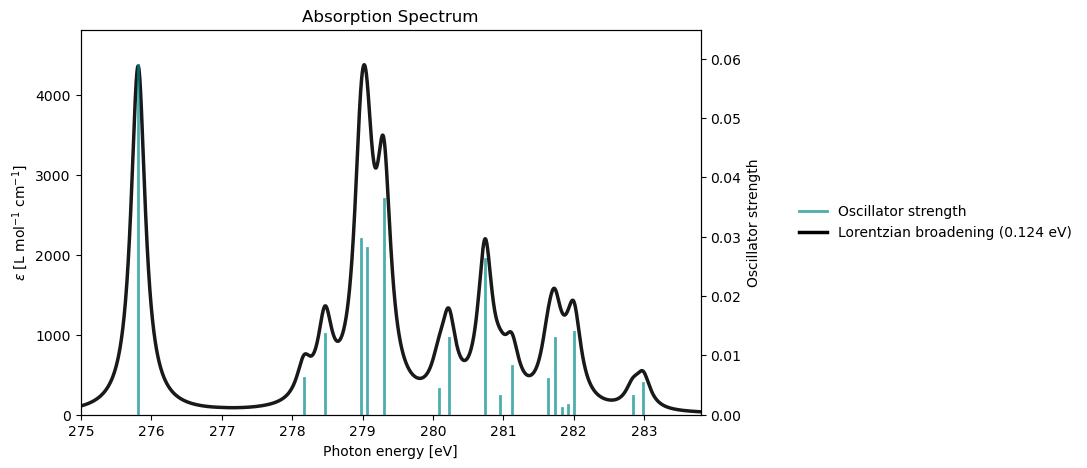

In [4]:
import veloxchem as vlx

molecule = vlx.Molecule.read_xyz_string("""13
ESCA b3lyp/def2-svp optimized geometry
C              1.326024532622         0.471089167011        -1.154937296389
C              0.484399509715         0.908494386259         0.037569541020
C              0.270494167717        -0.188493907246         1.053914467110
O              0.701245126416        -1.308212251798         0.971080711541
C             -0.582260522270         0.210893702941         2.291730106998
F             -0.731967860619        -0.799813015071         3.135965340271
F             -1.800383044157         0.625073687043         1.897202571864
F              0.003899498844         1.231896946553         2.943599980006
H              1.453639490166         1.302028888463        -1.864264306255
H              0.853135331881        -0.368249103011        -1.686230702784
H              2.322713498820         0.134038471332        -0.833394707486
H              0.936346512410         1.764030447212         0.571699332428
H             -0.514670521097         1.267150587304        -0.270103071648""")

basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp-100"
scf_results = scf_drv.compute(molecule, basis)

rsp_drv = vlx.LinearResponseEigenSolver()
rsp_drv.core_excitation = True

# Include all occupied orbitals up to and including the C 1s manifold
rsp_drv.num_core_orbitals = 8
rsp_drv.nstates = 20

rsp_results = rsp_drv.compute(molecule, basis, scf_results)
rsp_drv.plot_xas(rsp_results)

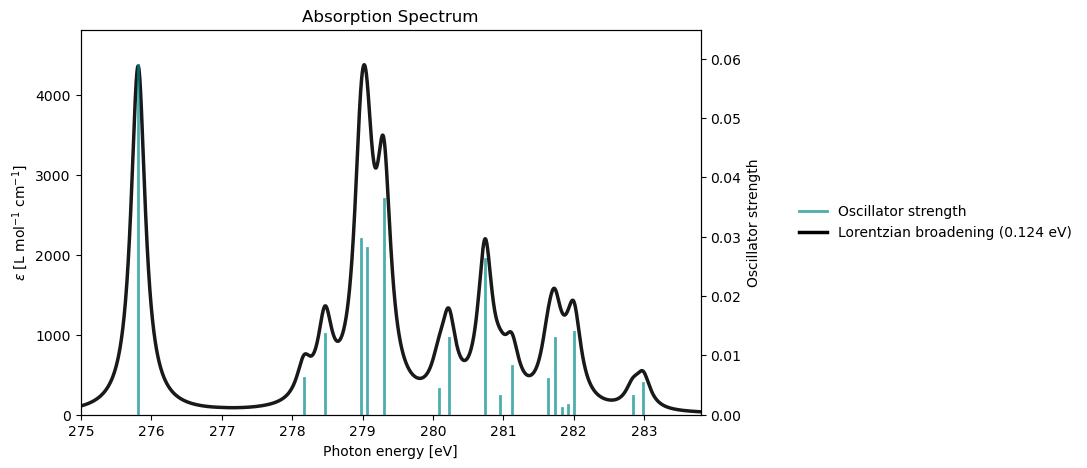

In [5]:
rsp_drv.plot_xas(rsp_results)

**Text file**

:::{code}
@jobs
task: response
@end

@method settings
xcfun: cam-b3lyp
basis: def2-svp
@end

@response
property: absorption
core_excitation: yes
num_core_orbitals: 8
nstates: 20
@end

@molecule
charge: 0
multiplicity: 1
xyz:  
...
@end 
:::

For the CVS calculation, `num_core_orbitals` is the number of occupied core orbitals included up to the edge of interest when the occupied orbitals are ordered by energy. For ESCA, `8` corresponds to the three F 1s orbitals, one O 1s orbital, and four C 1s orbitals, so it reaches and includes the full C 1s manifold.

(sec:xas-cpp)=
### XAS with CPP

In the CPP formulation, the absorption cross section is evaluated directly over a user-defined frequency window. This is useful when you want the near-edge spectral profile without solving explicitly for individual excited states.

**Python script**

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

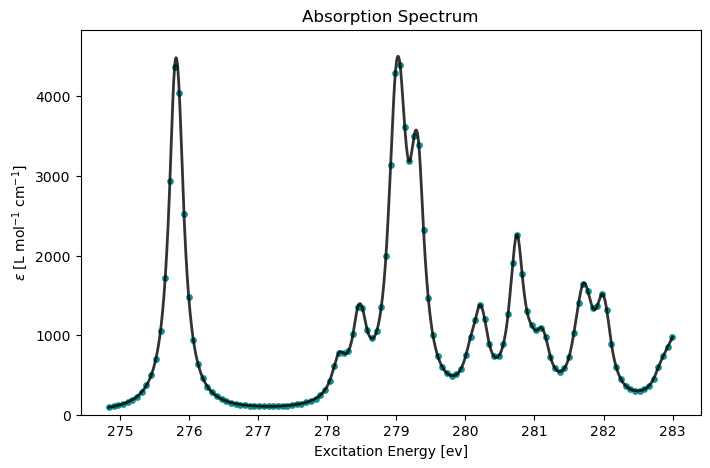

In [6]:
import veloxchem as vlx
import numpy as np

molecule = vlx.Molecule.read_xyz_string("""13
ESCA b3lyp/def2-svp optimized geometry
C              1.326024532622         0.471089167011        -1.154937296389
C              0.484399509715         0.908494386259         0.037569541020
C              0.270494167717        -0.188493907246         1.053914467110
O              0.701245126416        -1.308212251798         0.971080711541
C             -0.582260522270         0.210893702941         2.291730106998
F             -0.731967860619        -0.799813015071         3.135965340271
F             -1.800383044157         0.625073687043         1.897202571864
F              0.003899498844         1.231896946553         2.943599980006
H              1.453639490166         1.302028888463        -1.864264306255
H              0.853135331881        -0.368249103011        -1.686230702784
H              2.322713498820         0.134038471332        -0.833394707486
H              0.936346512410         1.764030447212         0.571699332428
H             -0.514670521097         1.267150587304        -0.270103071648""")

basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp-100"
scf_results = scf_drv.compute(molecule, basis)

cpp_drv = vlx.ComplexResponse()
cpp_drv.frequencies = np.arange(10.1, 10.4, 0.0025)
cpp_drv.property = "absorption"

cpp_results = cpp_drv.compute(molecule, basis, scf_results)
cpp_drv.plot(cpp_results, x_unit="eV")

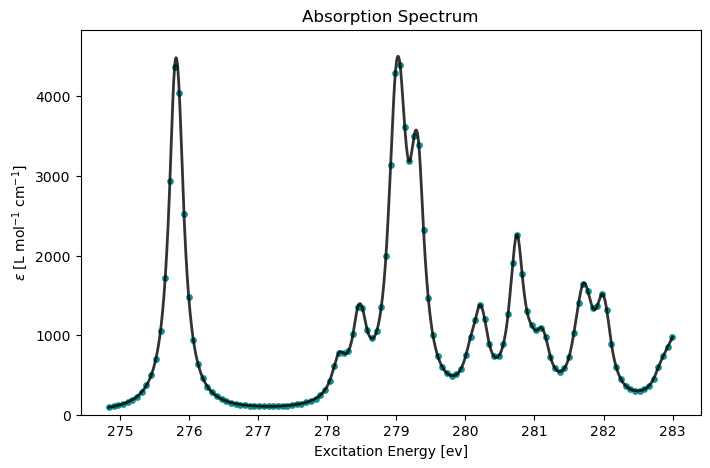

In [8]:
cpp_drv.plot(cpp_results, x_unit="eV")

**Text file**

:::{code}
@jobs
task: response
@end

@method settings
xcfun: cam-b3lyp
basis: def2-svp
@end

@response
property: absorption (cpp)
# frequency region (and resolution)
frequencies: 10.1-10.4 (0.0025)
@end

@molecule
charge: 0
multiplicity: 1
xyz:  
...
@end 
:::

Please refer to the [keyword list](#sec:cpp-keywords) for a complete set of CPP options.

(sec:rixs)=
## RIXS

RIXS is a photon-in$-$photon-out technique which transfers the element- and site-selectivity of XAS to the valence-excited state manifold. The double differential scattering cross-section corresponding to the electronic inelastic process is described within the Kramers-Heisenberg-Dirac (KHD) formulation:

$$
\frac{\mathrm{d}^2\sigma(\omega, \omega')}{\mathrm{d}\omega\,\,\mathrm{d}\omega'} = \left(\frac{r_e}{m_e}\right)^2\frac{\omega'}{\omega}\sum_{f}\left| \sum_n \frac{\langle f | \boldsymbol{\varepsilon'}\cdot\mathbf{\hat{p}} | n \rangle\langle n | \boldsymbol{\varepsilon}\cdot\mathbf{\hat{p}} | 0 \rangle}{\hbar(\omega + \omega_0 - \omega_n) + i\Gamma_n/2} \right|^2\delta(\omega' + \omega_{f0} - \omega)
$$

Here, $\hbar\omega$ and $\hbar\omega'$ are the incoming, respectively outgoing photon energies, $|0\rangle$ is the electronic ground state, $|f\rangle$ is a final valence-excited state, $|n\rangle$ is an intermediate core-excited state and $\hbar\omega_0$, $\hbar\omega_f$, and $\hbar\omega_n$ are their respective energies. The constants $r_e$ and $m_e$ are the classical electron radius, respectively the electron mass, while $\boldsymbol{\varepsilon}$ and $\boldsymbol{\varepsilon'}$ are, respectively, the incoming and outgoing polarization vectors. $\Gamma_n$ is the full-width-at-half-maximum lifetime broadening of the core-excited intermediate state $|n\rangle$.

Although computing RIXS scattering cross-sections formally requires quadratic response for the core-to-valence transition dipole moments, these second-order matrix elements may be approximated at first-order similarly as, e.g., for excited-state absorption. In this approach, the scattering cross-sections can be determined from two TDDFT calculations, one to obtain the valence-excited states and the other to obtain the core-excited states. The state-to-state transition density matrices are then computed using the linear-response (LR) eigenvectors. A detailed discussion of the theory, as well as a benchmark of the VeloxChem LR-TDDFT implementaion can be found in {cite}`vitols2025`.

RIXS calculations can be performed using the `RixsDriver`, as shown below.

**Python script**

In [7]:
import veloxchem as vlx

molecule = vlx.Molecule.read_xyz_string("""13
ESCA b3lyp/def2-svp optimized geometry
C              1.326024532622         0.471089167011        -1.154937296389
C              0.484399509715         0.908494386259         0.037569541020
C              0.270494167717        -0.188493907246         1.053914467110
O              0.701245126416        -1.308212251798         0.971080711541
C             -0.582260522270         0.210893702941         2.291730106998
F             -0.731967860619        -0.799813015071         3.135965340271
F             -1.800383044157         0.625073687043         1.897202571864
F              0.003899498844         1.231896946553         2.943599980006
H              1.453639490166         1.302028888463        -1.864264306255
H              0.853135331881        -0.368249103011        -1.686230702784
H              2.322713498820         0.134038471332        -0.833394707486
H              0.936346512410         1.764030447212         0.571699332428
H             -0.514670521097         1.267150587304        -0.270103071648""")

basis = vlx.MolecularBasis.read(molecule, "def2-svp")

xcfun = "cam-b3lyp"

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = xcfun
scf_results = scf_drv.compute(molecule, basis)

rixs_drv = vlx.RixsDriver()
rixs_drv.nstates = 20   # number of final valence-excited states
rixs_drv.num_core_orbitals = 8   # number of core orbitals
rixs_drv.num_core_states = 10  # number of intermediate core-excited states

rixs_drv.photon_energy = 276 / vlx.hartree_in_ev()  # value of the incoming photon energy in a.u.

rixs_results = rixs_drv.compute(molecule, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

:::{image} ../images/esca-rixs.png
:align: center
:width: 600px
:::

**Text file**

:::{code}
@jobs
task: response
@end

@method settings
xcfun: cam-b3lyp
basis: def2-svp
@end

@response
property: rixs
photon_energy: 10.1428
nstates: 20
num_core_orbitals: 8
num_core_states: 10
@end

@molecule
charge: 0
multiplicity: 1
xyz:  
...
@end

:::